# 1. Introdução

## 1.1. Contexto

Este notebook apresenta uma análise exploratória de um conjunto de dados sobre saúde mental de adolescentes e o uso de redes sociais. O objetivo é entender como variáveis como tempo de uso diário, sono, plataformas usadas e níveis de estresse, ansiedade e vício se relacionam com o rótulo de depressão.

## 1.2. Objetivos

- Carregar e inspecionar o dataset
- Limpar e preparar os dados para análise
- Explorar estatísticas descritivas de variáveis numéricas e categóricas
- Visualizar distribuições e padrões entre variáveis
- Identificar correlações e fatores associados ao rótulo de depressão
- Resumir as principais descobertas e limitações

# 2. Instalação e Importação das bibliotecas

In [ ]:
%pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Matplotlib is building the font cache; this may take a moment.


# 3. Carregamento dos Dados

In [3]:
# Carregar o dataset
path = 'data/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(path)

# Visão geral inicial
print('Dimensões do dataset:', df.shape)
print('\nAmostra inicial:')
display(df.head(10))

print('\nTipos de dados e valores não nulos:')
df.info()

print('\nDistribuição de depressão:')
print(df['depression_label'].value_counts(dropna=False))

print('\nValores únicos por coluna categórica:')
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    print(f'\n{col}:', df[col].value_counts().to_dict())

Dimensões do dataset: (1200, 13)

Amostra inicial:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0



Tipos de dados e valores não nulos:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memor

## 3.1. Compreensão das colunas
- **age**: idade do indivíduo.
- **daily_social_media_hours**: quantas horas por dia o indivíduo gasta nas redes sociais.
- **platform_usage**: As redes sociais mais usadas pelo indivíduo.
- **sleep_hours**: Horas de sono do indivíduo.
- **screen_time_before_sleep**: Quantas horas de tela o indivíduo gasta antes de dormir.
- **academic_performance**: Deempenho escolar do indivíduo.
- **physical_activity**: Nível de atividade física do indivíduo.
- **social_interaction_level**: Nível de interação social do indivíduo.
- **stress_level**: Nível de estresse.
- **anxiety_level**: Nível de ansiedade.
- **addiction_level**: Nível de vício ou compulsão.
- **depression_label**: Presença de depressão.

# 4. Limpeza e Preparação

Nessa etapa ocorre a limpeza dos dados para que seja possível entregar resultados mais precisos e confiáveis na análise. Algumas mudanças que foram feitas estão listadas logo abaixo:

- Conversão de tipos numéricos
- Padronização de colunas categóricas
- Normalização de strings
- Identificação e tratamento de duplicatas e valores ausentes

In [9]:
# Limpeza inicial e preparação dos dados

# Converter tipos numéricos e padronizar colunas categóricas
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Normalizar strings
string_cols = ['gender', 'platform_usage', 'social_interaction_level']
for col in string_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Padronizar gêneros
gender_map = {
    'male': 'male', 'm': 'male', 'man': 'male', 'masculino': 'male',
    'female': 'female', 'f': 'female', 'woman': 'female', 'feminino': 'female',
    'non-binary': 'other', 'nonbinary': 'other', 'other': 'other', 'trans': 'other',
    'prefer not to say': 'other', 'genderqueer': 'other', 'gender fluid': 'other',
}
df['gender'] = df['gender'].map(gender_map).fillna('other')

# Padronizar plataformas
platform_map = {
    'both': 'Both', 'instagram': 'Instagram', 'tiktok': 'TikTok', 'twitter': 'Twitter',
    'snapchat': 'Snapchat', 'facebook': 'Facebook', 'youtube': 'YouTube', 'whatsapp': 'WhatsApp'
}
df['platform_usage'] = df['platform_usage'].map(platform_map).fillna(df['platform_usage'].str.title())

# Padronizar nível de interação social
social_map = {'low': 'Low', 'medium': 'Medium', 'high': 'High'}
df['social_interaction_level'] = df['social_interaction_level'].map(social_map).fillna(df['social_interaction_level'].str.title())

# Converter rótulo em inteiro
if df['depression_label'].dtype != int:
    df['depression_label'] = pd.to_numeric(df['depression_label'], errors='coerce').astype('Int64')

# Identificar duplicatas e valores ausentes
duplicates = df.duplicated().sum()
missing_summary = df.isna().sum()

print('Duplicatas encontradas:', duplicates)
print('Valores ausentes por coluna:')
print(missing_summary)

# Não há tratamento agressivo aqui para manter o dataset íntegro;
# podemos continuar a análise mesmo com poucos valores ausentes.
df.drop_duplicates(inplace=True)
print('Dimensões após remoção de duplicatas:', df.shape)

Duplicatas encontradas: 0
Valores ausentes por coluna:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64
Dimensões após remoção de duplicatas: (1200, 13)


# 5. Análise Exploratória

## 5.1. Estatísticas Descritivas

In [5]:
# Estatísticas descritivas gerais
print('Descrição numérica das variáveis:')
display(df[numeric_cols].describe().T)

print('\nContagem por rótulo de depressão:')
display(df['depression_label'].value_counts().rename('count').to_frame())

def categorical_summary(column):
    summary = df[column].value_counts().rename('count').to_frame()
    summary['percent'] = (summary['count'] / len(df)) * 100
    return summary

print('\nResumo das categorias de gênero:')
display(categorical_summary('gender'))

print('\nResumo de uso de plataforma:')
display(categorical_summary('platform_usage'))

print('\nResumo de interação social:')
display(categorical_summary('social_interaction_level'))

Descrição numérica das variáveis:


,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.50,6.30,8.0
sleep_hours,1200.0,6.449417,1.442677,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5,1.1,1.80,2.40,3.0
academic_performance,1200.0,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,1.014500,0.582185,0.0,0.5,1.00,1.50,2.0
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.00,8.00,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.00,8.00,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.00,8.00,10.0



Contagem por rótulo de depressão:


,count
depression_label,
0,1169
1,31



Resumo das categorias de gênero:


,count,percent
gender,,
male,615,51.25
female,585,48.75



Resumo de uso de plataforma:


,count,percent
platform_usage,,
Instagram,411,34.250000
TikTok,398,33.166667
Both,391,32.583333



Resumo de interação social:


,count,percent
social_interaction_level,,
Medium,416,34.666667
Low,415,34.583333
High,369,30.750000


Mediante os resultados das estatísticas descritivas do nosso dataset, podemos extrair algumas informações interessantes:

- De 100% dos indivíduos registrados, o indicador de depressão consta como positivo para cerca de 3% deles.
- A maior parte dos indivíduos registrados são do gênero masculino.
- O Instagram é mais usado pelos indivíduos em comparação com o TikTok ou os dois juntos.
- Grande parte dos indivíduos registrados no dataset possuem um nível de interação social que varia entre baixo e médio.

## 5.2. Distribuições

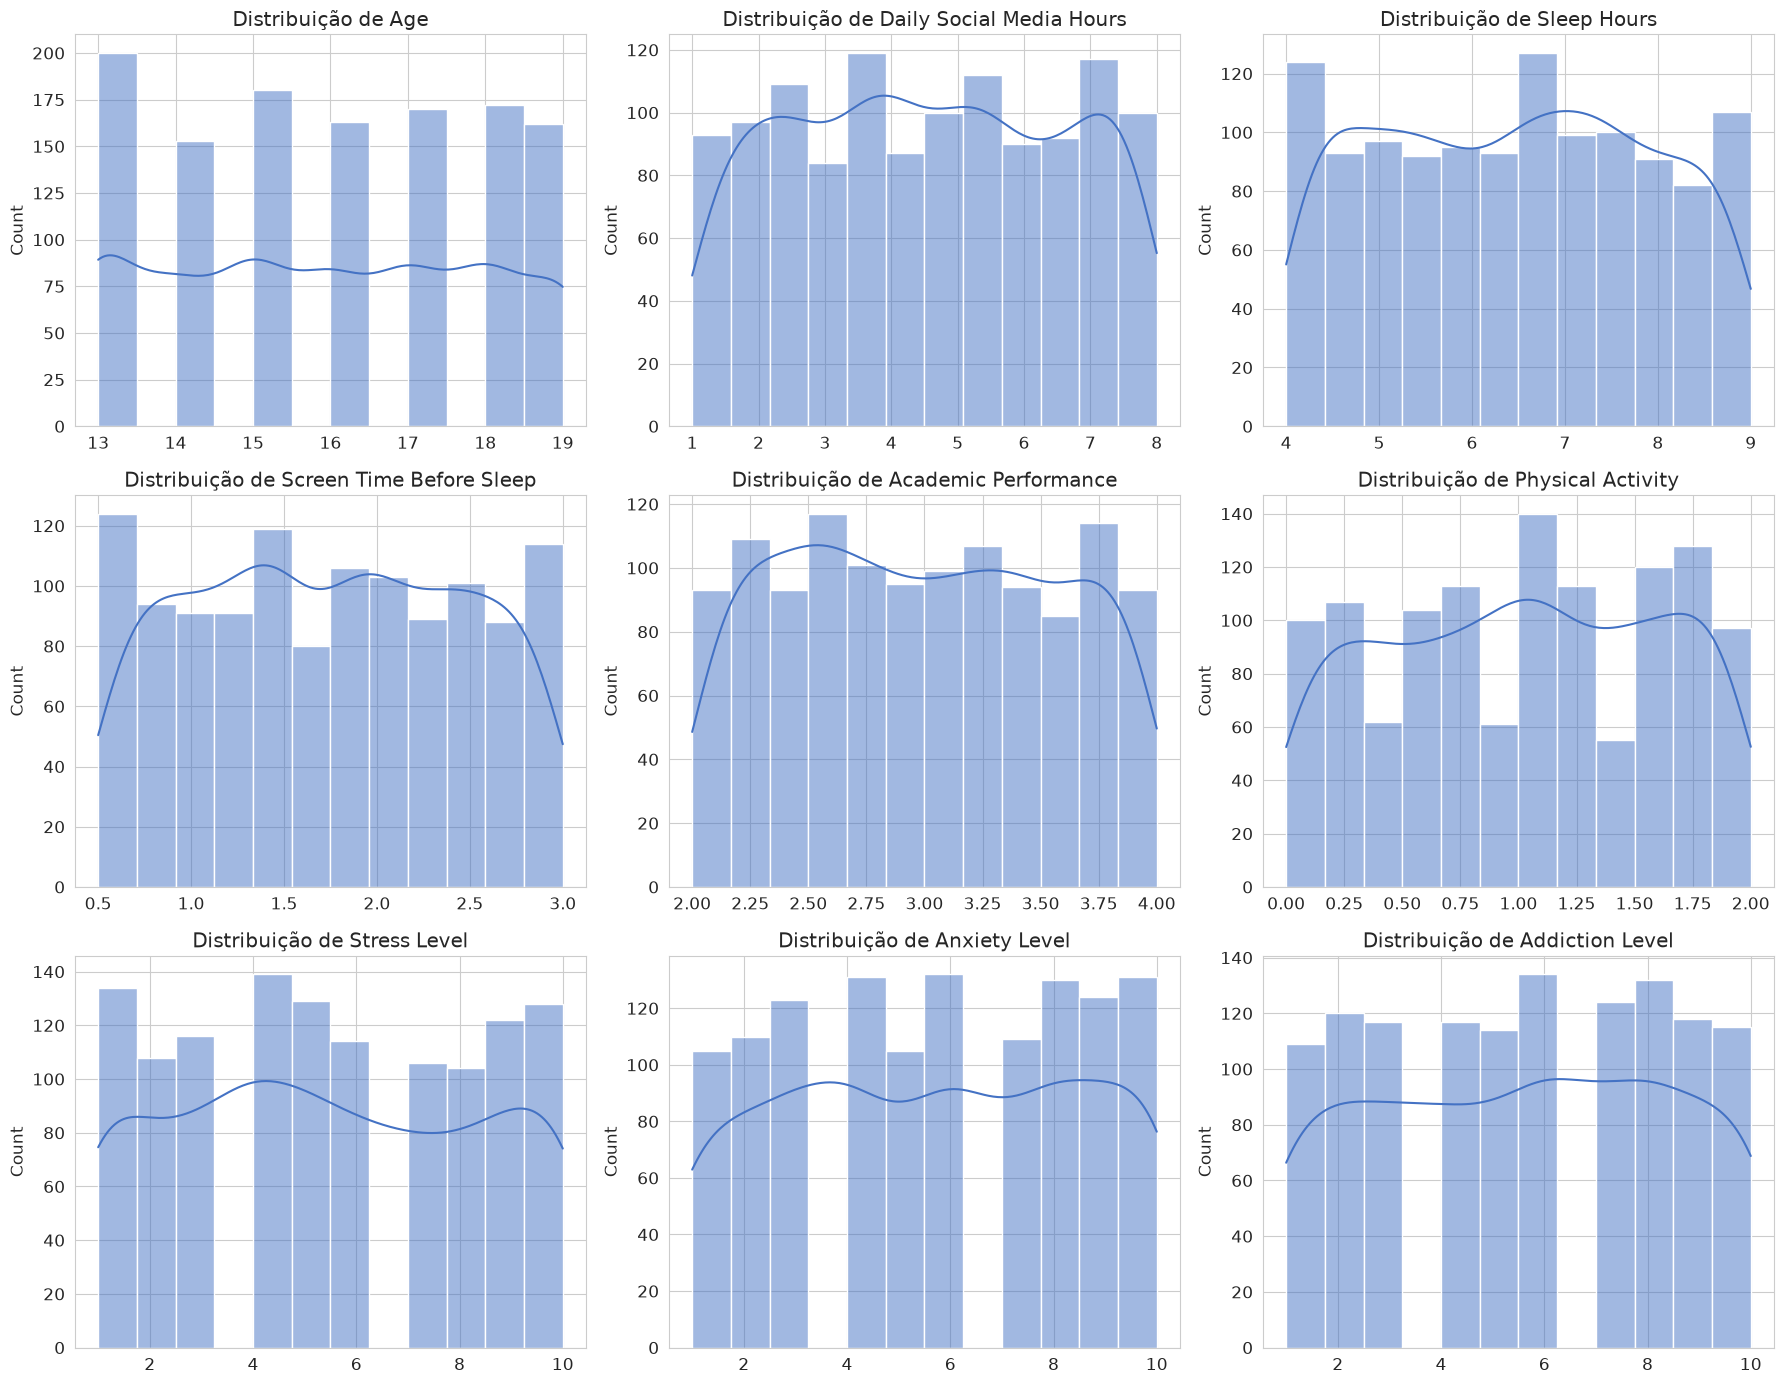

/tmp/ipykernel_253863/973414421.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index, ax=axes[0], palette='pastel')
/tmp/ipykernel_253863/973414421.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='platform_usage', order=df['platform_usage'].value_counts().index, ax=axes[1], palette='pastel')
/tmp/ipykernel_253863/973414421.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='social_interaction_level', order=['Low', 'Medium', 'High'], ax=axes[2], pa

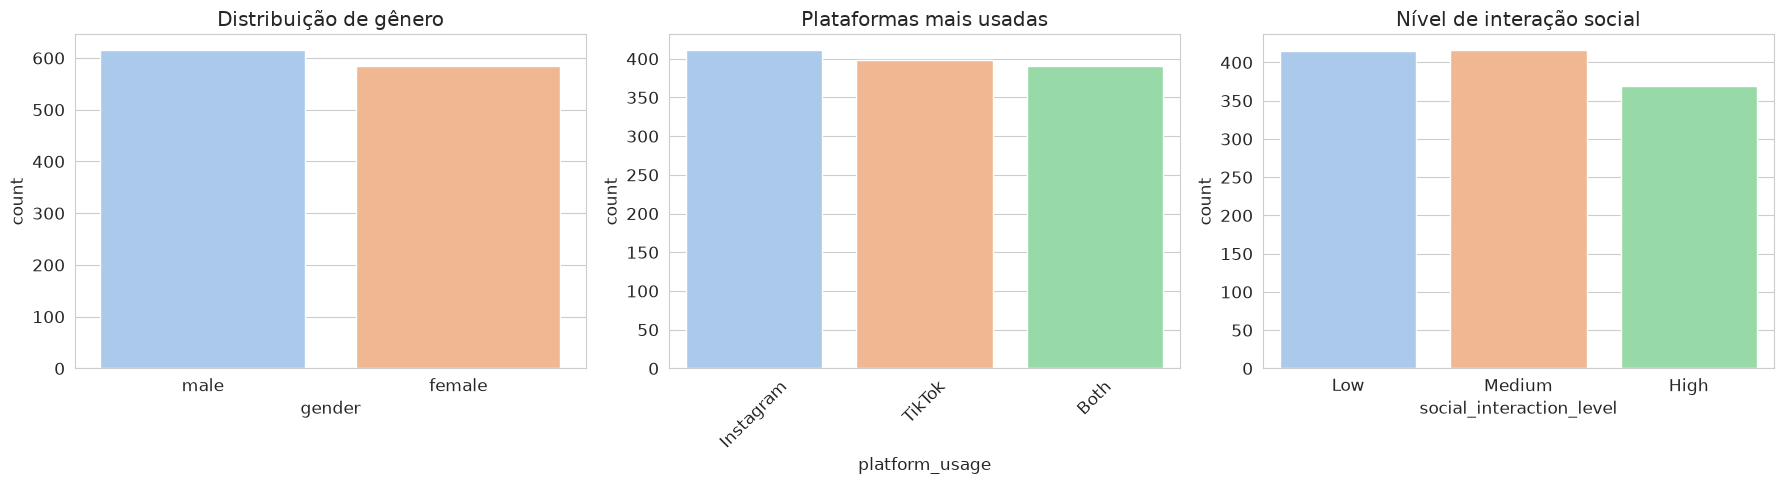

/tmp/ipykernel_253863/973414421.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_253863/973414421.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_253863/973414421.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_253863/973414421.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

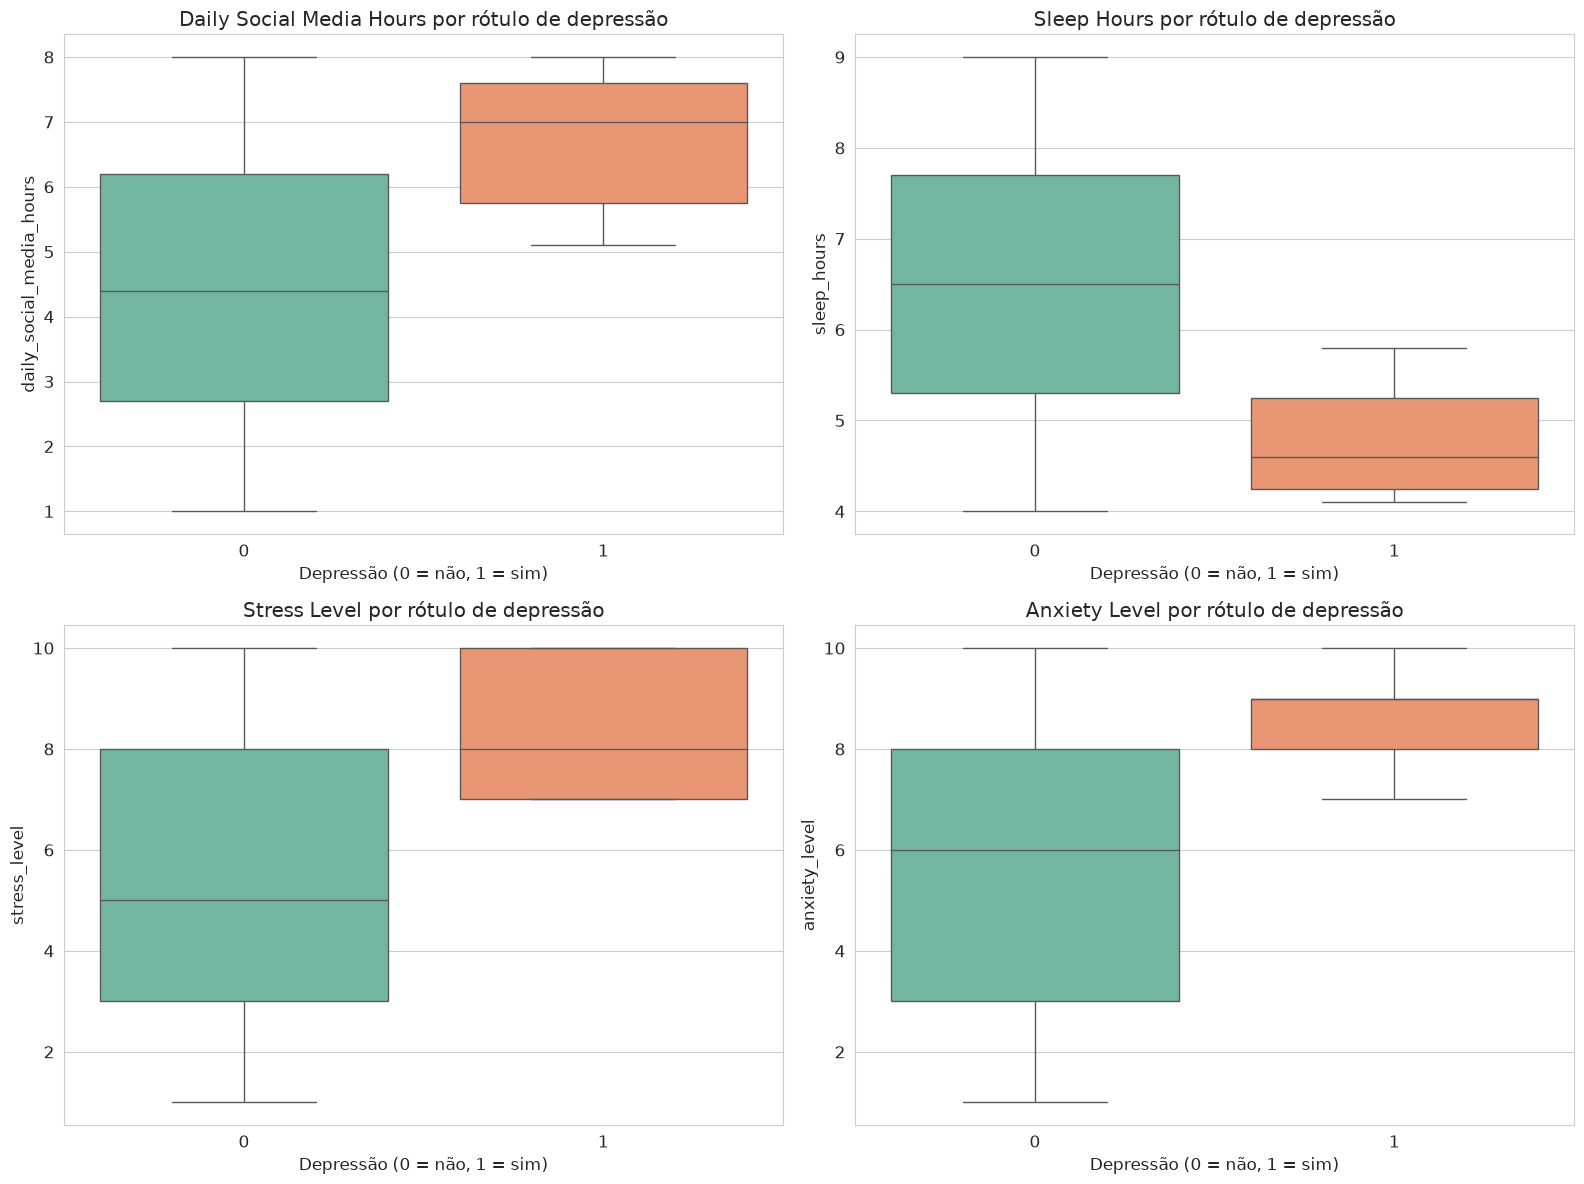

In [6]:
# Distribuições das variáveis numéricas e categóricas

# Distribuições numéricas
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#4472c4')
    ax.set_title(f'Distribuição de {col.replace("_", " ").title()}')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Contagem de categorias relevantes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index, ax=axes[0], palette='pastel')
axes[0].set_title('Distribuição de gênero')

sns.countplot(data=df, x='platform_usage', order=df['platform_usage'].value_counts().index, ax=axes[1], palette='pastel')
axes[1].set_title('Plataformas mais usadas')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='social_interaction_level', order=['Low', 'Medium', 'High'], ax=axes[2], palette='pastel')
axes[2].set_title('Nível de interação social')
plt.tight_layout()
plt.show()

# Boxplots por depressão
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_cols = ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level']
for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(data=df, x='depression_label', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col.replace("_", " ").title()} por rótulo de depressão')
    ax.set_xlabel('Depressão (0 = não, 1 = sim)')
plt.tight_layout()
plt.show()

...

## 5.3. Correlações

Para entender melhor como as variáveis se relacionam, montamos uma matriz de correlação que mostra visualmente o grau de influência entre pares de variáveis. Logo depois, focamos em entender como as variáveis sozinhas influenciam a presença de depressão nos indivíduos.

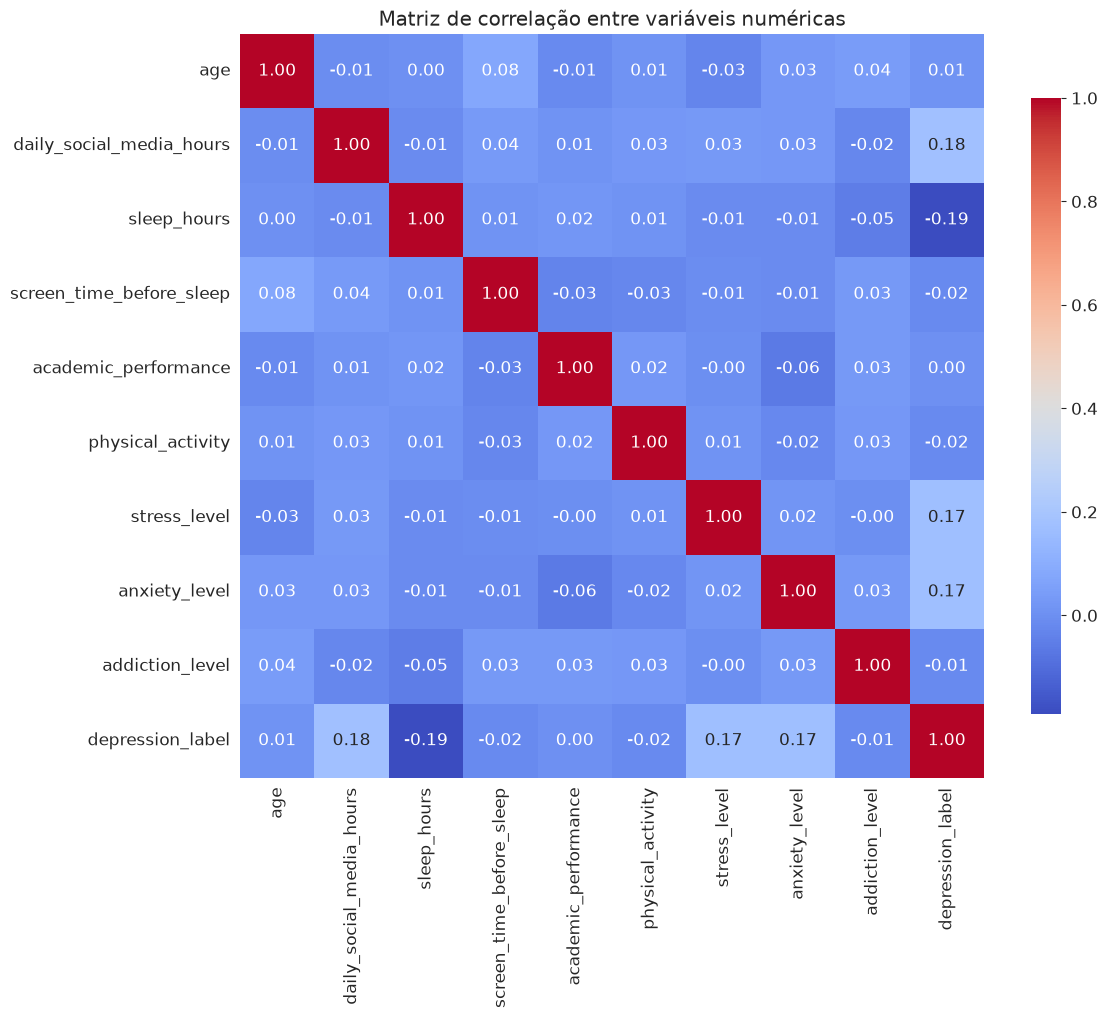

Correlação das variáveis numéricas com o rótulo de depressão:
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64


In [7]:
# Correlação entre as variáveis numéricas
corr_matrix = df[numeric_cols + ['depression_label']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação entre variáveis numéricas')
plt.show()

# Correlação direta com o rótulo de depressão
target_corr = corr_matrix['depression_label'].drop('depression_label').sort_values(ascending=False)
print('Correlação das variáveis numéricas com o rótulo de depressão:')
print(target_corr)

No geral, todas as variáveis possuem uma correlação linear fraca com o indicador de depressão, uma vez que os coeficientes de correlação estão todos próximos de zero.

As maiores correlações positivas observadas foram:

- `daily_social_media_hours` (r = 0.175)
- `stress_level` (r = 0.170)
- `anxiety_level` (r = 0.170)

Isso sugere que maiores níveis de uso diário de redes sociais, estresse e ansiedade tendem a estar associados a uma maior probabilidade de depressão, embora a força dessa associação seja baixa.

Por outro lado, a variável com maior correlação negativa foi: `sleep_hours` (r = -0.191)

Esse resultado indica que indivíduos com maior quantidade de horas de sono tendem a apresentar menor probabilidade de depressão.

Em resumo, a análise de correlação sugere que nenhuma variável isoladamente explica de forma significativa a ocorrência de depressão, indicando a possibilidade de relações não lineares ou da influência conjunta de múltiplos fatores.

# 6. Visualizações

/tmp/ipykernel_253863/2450116351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='depression_label', palette=['#82c0ff', '#ff9999'])


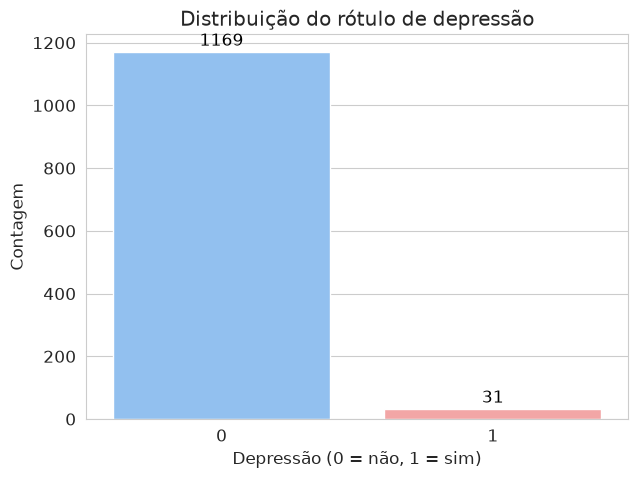

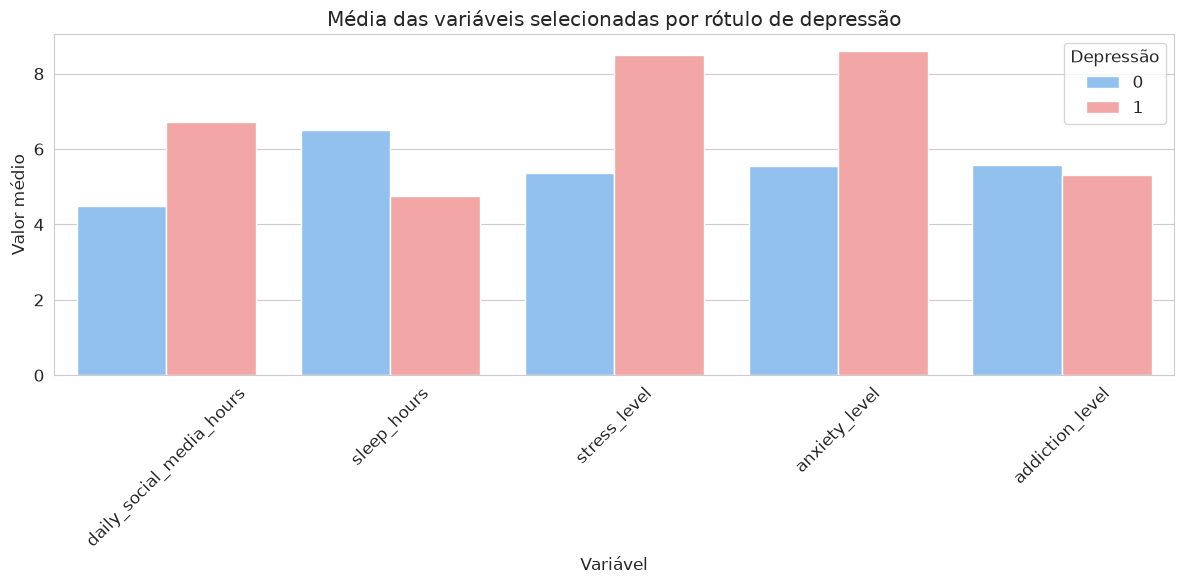

/tmp/ipykernel_253863/2450116351.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_rate.index, y=platform_rate.values, palette='viridis')


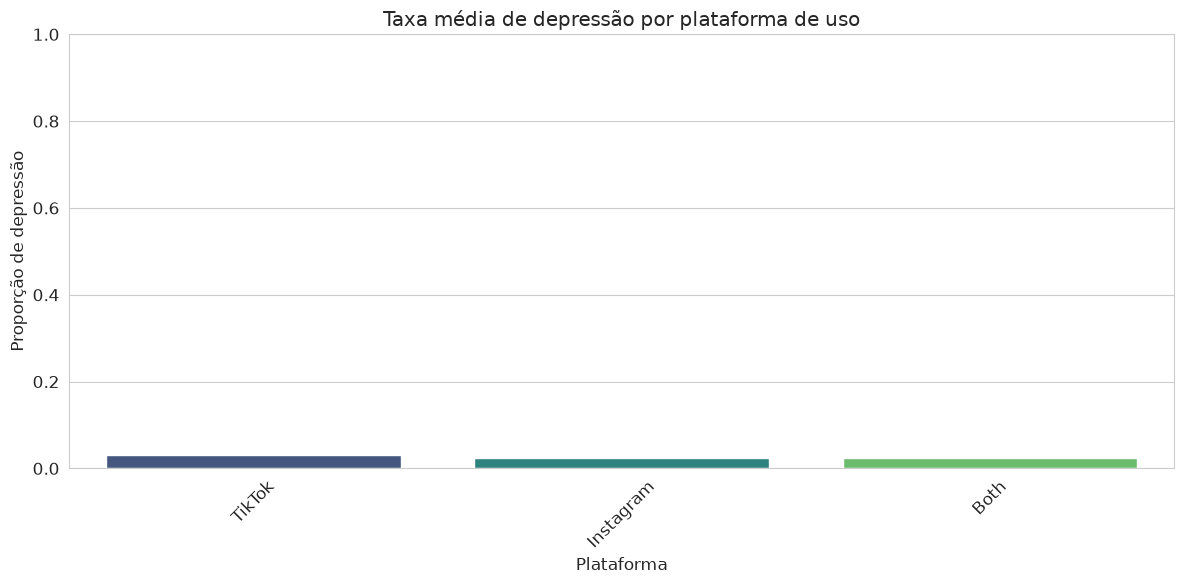

/tmp/ipykernel_253863/2450116351.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=social_rate.index, y=social_rate.values, palette='magma')


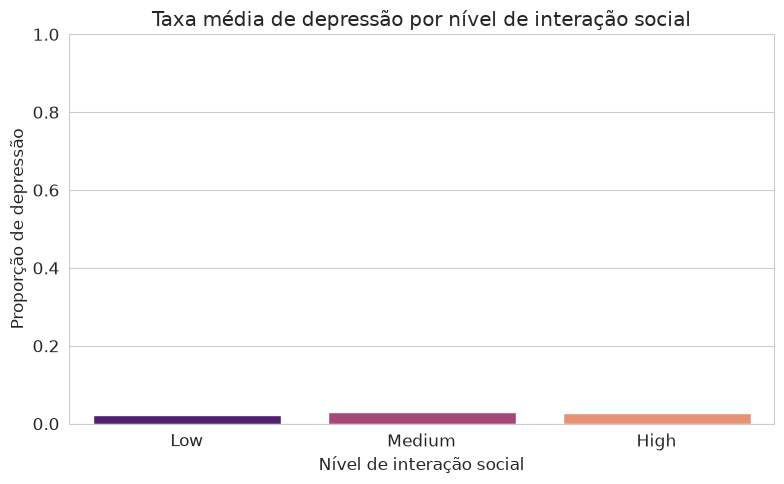

In [8]:
# Visualizações de relacionamentos importantes

# Distribuição do rótulo de depressão
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='depression_label', palette=['#82c0ff', '#ff9999'])
ax.set_title('Distribuição do rótulo de depressão')
ax.set_xlabel('Depressão (0 = não, 1 = sim)')
ax.set_ylabel('Contagem')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 8), textcoords='offset points')
plt.show()

# Comparar médias por rótulo de depressão
compare_cols = ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', 'addiction_level']
mean_df = df.groupby('depression_label')[compare_cols].mean().reset_index()
mean_df_melted = mean_df.melt(id_vars='depression_label', var_name='feature', value_name='mean_value')
plt.figure(figsize=(12, 6))
sns.barplot(data=mean_df_melted, x='feature', y='mean_value', hue='depression_label', palette=['#82c0ff', '#ff9999'])
plt.title('Média das variáveis selecionadas por rótulo de depressão')
plt.xlabel('Variável')
plt.ylabel('Valor médio')
plt.xticks(rotation=45)
plt.legend(title='Depressão')
plt.tight_layout()
plt.show()

# Relação entre plataforma e depressão
plt.figure(figsize=(12, 6))
platform_rate = df.groupby('platform_usage')['depression_label'].mean().sort_values(ascending=False)
sns.barplot(x=platform_rate.index, y=platform_rate.values, palette='viridis')
plt.title('Taxa média de depressão por plataforma de uso')
plt.xlabel('Plataforma')
plt.ylabel('Proporção de depressão')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Relação entre interação social e depressão
plt.figure(figsize=(8, 5))
social_rate = df.groupby('social_interaction_level')['depression_label'].mean().reindex(['Low', 'Medium', 'High'])
sns.barplot(x=social_rate.index, y=social_rate.values, palette='magma')
plt.title('Taxa média de depressão por nível de interação social')
plt.xlabel('Nível de interação social')
plt.ylabel('Proporção de depressão')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 7. Conclusões

## Principais descobertas

- O dataset contém informações sobre comportamento de adolescentes em relação ao uso de redes sociais e seus indicadores de saúde mental.
- A variável `depression_label` é binária e permite observar diferenças claras em variáveis como horas de sono, níveis de estresse, ansiedade e dependência de redes sociais.
- A correlação mostra que `stress_level`, `anxiety_level` e `addiction_level` têm associação positiva mais forte com o rótulo de depressão.
- A plataforma de uso e a interação social também apresentam variações no percentual de depressão, sugerindo que hábitos e contexto social podem ser fatores importantes.

## Limitações

- O dataset é relativamente pequeno e não contém amostras de todas as faixas demográficas.
- Algumas colunas foram convertidas para categorias simplificadas, e a qualidade dos dados depende de respostas auto-relatadas.
- A análise aqui é exploratória e não estabelece relações causais.

## Próximos passos

- Construir um modelo de classificação para prever `depression_label` a partir das variáveis de comportamento.
- Aplicar técnicas de engenharia de features e validação cruzada para avaliar robustez.
- Coletar mais dados e adicionar informações demográficas adicionais para melhorar a generalização.